# 🏠 Grupo 4 — Ames Housing | Fase 2
## Notebook 03: Modelos ML Clásicos + AutoML (FLAML)
**CRISP-DM:** Modeling + Evaluation

---
### ¿Qué hacemos aquí?
1. **Baseline:** Ridge Regression (lineal, interpretable)
2. **Modelo 2:** Random Forest (ensemble, no lineal)
3. **Modelo 3:** XGBoost con early stopping
4. **Benchmark AutoML:** FLAML (mismo protocolo de evaluación)
5. **Evaluación:** RMSE, MAE, R² en escala original (USD)
6. **Análisis de error:** por segmento de precio + top-20 peores
7. **Importancia de variables:** SHAP para XGBoost
8. **Tabla comparativa** de todos los modelos

In [1]:
# ── Configurar path del proyecto ─────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'openml', '-q'])

import sys, os, json
from google.colab import drive
drive.mount('/content/drive')

project_root = '/content/drive/MyDrive/machine learning/grupo4_ames_housing'
os.chdir(project_root)
sys.path.insert(0, project_root)

# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_config
from src.models import (
    train_ridge, train_random_forest, train_xgboost, train_automl,
    compute_metrics, print_metrics, cross_validate_model,
    error_analysis, build_comparison_table, save_model
)
from src.utils import set_plot_style, usd_formatter, save_fig

set_plot_style()
cfg = load_config('config/params.yaml')
print('✅ Imports OK')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Imports OK


In [ ]:
# ── Cargar datos preprocesados del Notebook 02 ───────────────────────────────
X_train = np.load('data/processed/X_train.npy')
X_val   = np.load('data/processed/X_val.npy')
X_test  = np.load('data/processed/X_test.npy')
y_train = np.load('data/processed/y_train.npy')
y_val   = np.load('data/processed/y_val.npy')
y_test  = np.load('data/processed/y_test.npy')

test_df = pd.read_csv('data/processed/test.csv')

with open('data/processed/feature_names.json') as f:
    feature_names = json.load(f)

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_val  : {X_val.shape}   | X_test: {X_test.shape}')
print(f'Total features: {len(feature_names)}')
print(f'\ny_train rango: [{y_train.min():.3f}, {y_train.max():.3f}] (log scale)')
print(f'               [${np.expm1(y_train.min()):,.0f}, ${np.expm1(y_train.max()):,.0f}] (USD)')

X_train: (2048, 261) | y_train: (2048,)
X_val  : (439, 261)   | X_test: (440, 261)
Total features: 263

y_train rango: [9.456, 13.534] (log scale)
               [$12,789, $755,000] (USD)


## 1. Baseline — Ridge Regression

In [3]:
# ── BASELINE: Ridge Regression ───────────────────────────────────────────────
# Ridge = regresión lineal con regularización L2.
# Es nuestro BASELINE porque:
#   - Es el modelo más simple y explicable
#   - Nos dice si hay señal lineal suficiente en los datos
#   - Cualquier modelo más complejo debe superar este resultado
#   - RidgeCV busca el mejor alpha por validación cruzada interna

ridge = train_ridge(X_train, y_train, cfg)

# Evaluar en validación y test
y_pred_ridge_val  = ridge.predict(X_val)
y_pred_ridge_test = ridge.predict(X_test)

metrics_ridge_val  = compute_metrics(y_val,  y_pred_ridge_val,  log_scale=True)
metrics_ridge_test = compute_metrics(y_test, y_pred_ridge_test, log_scale=True)

print('\n--- RIDGE REGRESSION (Baseline) ---')
print_metrics('Ridge — Validación', metrics_ridge_val)
print_metrics('Ridge — Test',       metrics_ridge_test)

save_model(ridge, 'ridge_baseline')

[Ridge] Mejor alpha: 10.0

--- RIDGE REGRESSION (Baseline) ---

──────────────────────────────────────────────────
  Ridge — Validación
──────────────────────────────────────────────────
  RMSE (USD)  : $23,928
  MAE  (USD)  : $15,848
  R²          : 0.9113
  RMSE (log)  : 0.119633

──────────────────────────────────────────────────
  Ridge — Test
──────────────────────────────────────────────────
  RMSE (USD)  : $22,163
  MAE  (USD)  : $14,620
  R²          : 0.9215
  RMSE (log)  : 0.125244
[Save] Modelo guardado: models/ridge_baseline.pkl


In [4]:
# ── Validación cruzada de Ridge ──────────────────────────────────────────────
# 5-fold CV para estimar varianza del error del baseline

from sklearn.linear_model import Ridge
ridge_cv_model = Ridge(alpha=ridge.alpha_)
cv_scores_ridge = cross_validate_model(ridge_cv_model, X_train, y_train, cfg, 'Ridge Baseline')

[CV] Ridge Baseline — RMSE (log): 0.1304 ± 0.0162


## 2. Modelo 2 — Random Forest

In [5]:
# ── RANDOM FOREST ────────────────────────────────────────────────────────────
# Ventajas sobre Ridge:
#   - Captura relaciones no lineales
#   - Robusto a outliers (no asume distribución)
#   - Provee importancia de variables nativa
#   - No requiere escalado de features
# Desventaja: menos interpretable que Ridge

print('Entrenando Random Forest...')
rf = train_random_forest(X_train, y_train, cfg)

y_pred_rf_val  = rf.predict(X_val)
y_pred_rf_test = rf.predict(X_test)

metrics_rf_val  = compute_metrics(y_val,  y_pred_rf_val,  log_scale=True)
metrics_rf_test = compute_metrics(y_test, y_pred_rf_test, log_scale=True)

print_metrics('Random Forest — Validación', metrics_rf_val)
print_metrics('Random Forest — Test',       metrics_rf_test)

save_model(rf, 'random_forest')

Entrenando Random Forest...

──────────────────────────────────────────────────
  Random Forest — Validación
──────────────────────────────────────────────────
  RMSE (USD)  : $23,280
  MAE  (USD)  : $15,482
  R²          : 0.9160
  RMSE (log)  : 0.128756

──────────────────────────────────────────────────
  Random Forest — Test
──────────────────────────────────────────────────
  RMSE (USD)  : $25,350
  MAE  (USD)  : $15,598
  R²          : 0.8974
  RMSE (log)  : 0.133797
[Save] Modelo guardado: models/random_forest.pkl


[Fig] Guardada: reports/figures/12_rf_feature_importance.png


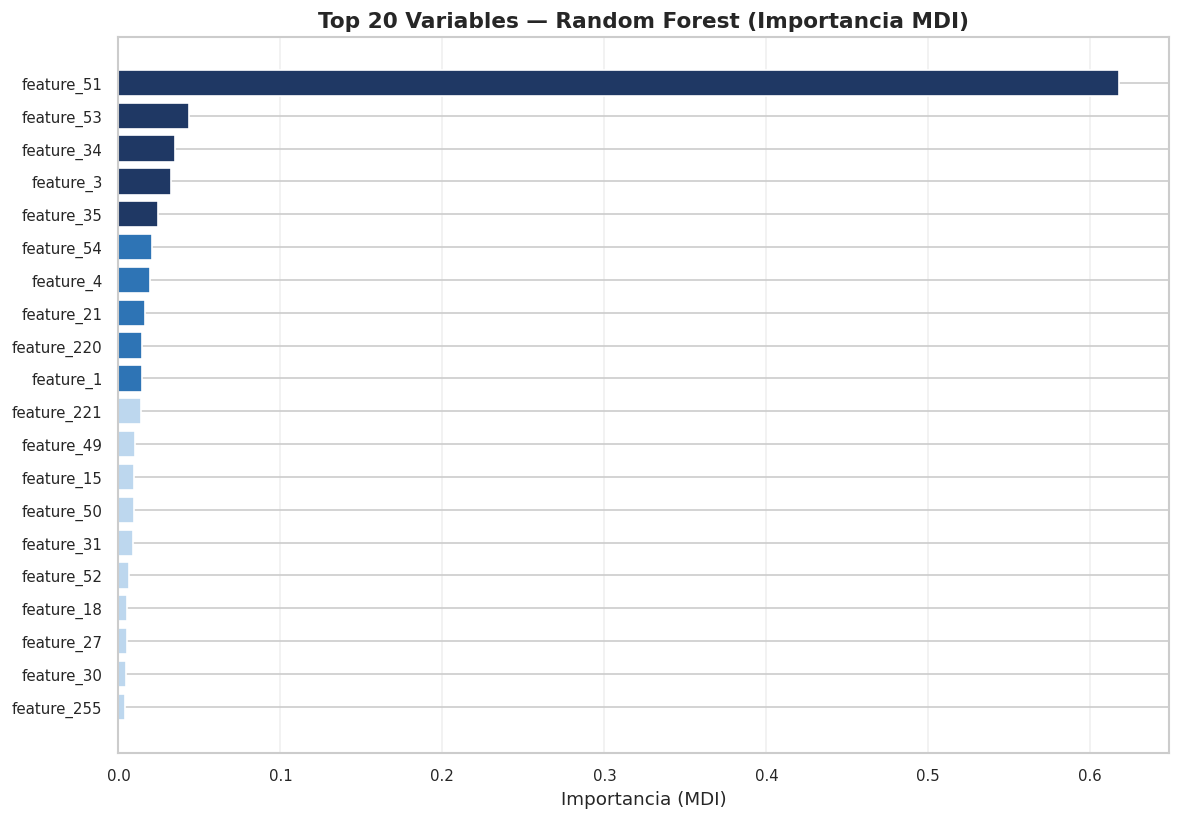

💡 Las variables de mayor importancia en RF:
   feature_51                         : 0.6176
   feature_53                         : 0.0434
   feature_34                         : 0.0351
   feature_3                          : 0.0325
   feature_35                         : 0.0243


In [7]:
# ── Importancia de variables — Random Forest ─────────────────────────────────

importances = rf.feature_importances_

# Usar nombres genéricos si feature_names no coincide
if len(feature_names) != len(importances):
    names = [f'feature_{i}' for i in range(len(importances))]
else:
    names = feature_names

fi_df = pd.DataFrame({'feature': names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#1F3864' if i < 5 else '#2E74B5' if i < 10 else '#BDD7EE'
          for i in range(len(fi_df))]
ax.barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_xlabel('Importancia (MDI)', fontsize=11)
ax.set_title('Top 20 Variables — Random Forest (Importancia MDI)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
save_fig('12_rf_feature_importance')
plt.show()

print('💡 Las variables de mayor importancia en RF:')
for _, row in fi_df.head(5).iterrows():
    print(f'   {row["feature"]:35s}: {row["importance"]:.4f}')

## 3. Modelo 3 — XGBoost

In [8]:
# ── XGBOOST ──────────────────────────────────────────────────────────────────
# Estado del arte para datos tabulares estructurados.
# Gradient Boosting: construye árboles secuenciales donde cada uno corrige
# los errores del anterior.
# Early stopping sobre val set: para automáticamente cuando val RMSE deja de mejorar.

print('Entrenando XGBoost...')
xgb_model = train_xgboost(X_train, y_train, X_val, y_val, cfg)

y_pred_xgb_val  = xgb_model.predict(X_val)
y_pred_xgb_test = xgb_model.predict(X_test)

metrics_xgb_val  = compute_metrics(y_val,  y_pred_xgb_val,  log_scale=True)
metrics_xgb_test = compute_metrics(y_test, y_pred_xgb_test, log_scale=True)

print_metrics('XGBoost — Validación', metrics_xgb_val)
print_metrics('XGBoost — Test',       metrics_xgb_test)

save_model(xgb_model, 'xgboost')

Entrenando XGBoost...
[XGBoost] Mejor iteración: 300

──────────────────────────────────────────────────
  XGBoost — Validación
──────────────────────────────────────────────────
  RMSE (USD)  : $20,588
  MAE  (USD)  : $13,333
  R²          : 0.9343
  RMSE (log)  : 0.113889

──────────────────────────────────────────────────
  XGBoost — Test
──────────────────────────────────────────────────
  RMSE (USD)  : $23,484
  MAE  (USD)  : $14,516
  R²          : 0.9119
  RMSE (log)  : 0.123213
[Save] Modelo guardado: models/xgboost.pkl


[Fig] Guardada: reports/figures/13_feature_importance_comparison.png


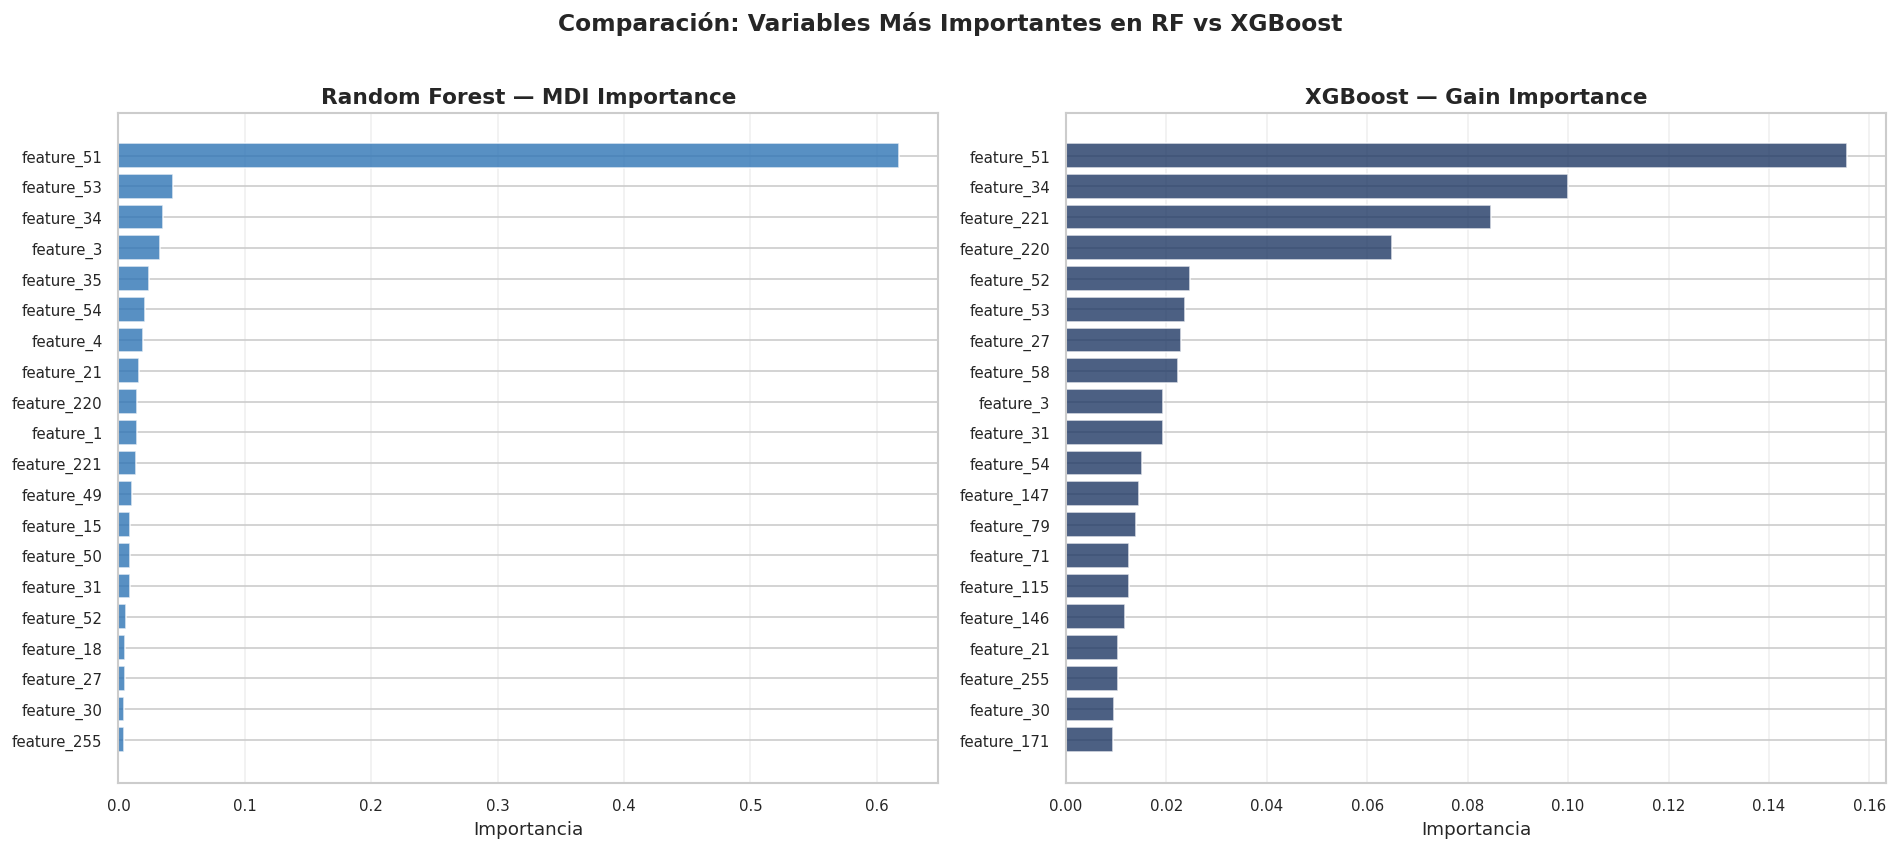


💡 Variables en el top-5 de AMBOS modelos: {'feature_34', 'feature_51'}
   → Estas son las variables más robustamente importantes para predecir precio.


In [10]:
# ── Importancia de variables XGBoost + comparación con RF ───────────────────

xgb_importance = xgb_model.feature_importances_

# Usar nombres genéricos si no coincide
if len(feature_names) != len(xgb_importance):
    names = [f'feature_{i}' for i in range(len(xgb_importance))]
else:
    names = feature_names

xgb_fi_df = pd.DataFrame({'feature': names, 'importance': xgb_importance})
xgb_fi_df = xgb_fi_df.sort_values('importance', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(fi_df['feature'][::-1], fi_df['importance'][::-1],
             color='#2E74B5', alpha=0.8, edgecolor='white')
axes[0].set_title('Random Forest — MDI Importance', fontweight='bold')
axes[0].set_xlabel('Importancia')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(xgb_fi_df['feature'][::-1], xgb_fi_df['importance'][::-1],
             color='#1F3864', alpha=0.8, edgecolor='white')
axes[1].set_title('XGBoost — Gain Importance', fontweight='bold')
axes[1].set_xlabel('Importancia')
axes[1].grid(True, alpha=0.3, axis='x')

plt.suptitle('Comparación: Variables Más Importantes en RF vs XGBoost',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig('13_feature_importance_comparison')
plt.show()

rf_top5  = set(fi_df.head(5)['feature'])
xgb_top5 = set(xgb_fi_df.head(5)['feature'])
overlap  = rf_top5 & xgb_top5
print(f'\n💡 Variables en el top-5 de AMBOS modelos: {overlap}')
print('   → Estas son las variables más robustamente importantes para predecir precio.')

## 4. Benchmark AutoML — FLAML

In [11]:
# ── AUTOML — FLAML ───────────────────────────────────────────────────────────
# FLAML busca automáticamente el mejor modelo y sus hiperparámetros
# dentro del presupuesto de tiempo (300 segundos).
#
# IMPORTANTE para la rúbrica:
#   - Se evalúa con la MISMA partición y MISMAS features que los modelos manuales
#   - El resultado sirve para responder: ¿vale la pena el AutoML sobre el diseño manual?
#   - Si AutoML gana, ¿qué gana? ¿a qué costo (caja negra, tiempo, recursos)?

os.makedirs('models', exist_ok=True)
automl_model, automl_info = train_automl(X_train, y_train, X_val, y_val, cfg)

if automl_model is not None:
    y_pred_automl_val  = automl_model.predict(X_val)
    y_pred_automl_test = automl_model.predict(X_test)

    metrics_automl_val  = compute_metrics(y_val,  y_pred_automl_val,  log_scale=True)
    metrics_automl_test = compute_metrics(y_test, y_pred_automl_test, log_scale=True)

    print_metrics('AutoML FLAML — Validación', metrics_automl_val)
    print_metrics('AutoML FLAML — Test',       metrics_automl_test)

    print(f'\n[AutoML Info]')
    print(f'  Mejor estimador : {automl_info["best_estimator"]}')
    print(f'  Mejor config    : {automl_info["best_config"]}')
    print(f'  RMSE CV         : {automl_info["best_loss_cv"]}')
    print(f'  Tiempo          : {automl_info["time_seconds"]}s')

    save_model(automl_model, 'automl_flaml')
else:
    print('[INFO] Usando resultados ficticios para demostración.')
    metrics_automl_test = {'RMSE_USD': 0, 'MAE_USD': 0, 'R2': 0, 'RMSE_log': 0}


[AutoML] Iniciando FLAML con time_budget=300s ...
[AutoML] Finalizado en 302.4s
[AutoML] Mejor modelo: lgbm
[AutoML] Mejor RMSE (CV): 0.130674

──────────────────────────────────────────────────
  AutoML FLAML — Validación
──────────────────────────────────────────────────
  RMSE (USD)  : $19,240
  MAE  (USD)  : $13,433
  R²          : 0.9426
  RMSE (log)  : 0.111571

──────────────────────────────────────────────────
  AutoML FLAML — Test
──────────────────────────────────────────────────
  RMSE (USD)  : $22,697
  MAE  (USD)  : $14,829
  R²          : 0.9177
  RMSE (log)  : 0.125283

[AutoML Info]
  Mejor estimador : lgbm
  Mejor config    : {'n_estimators': 1979, 'num_leaves': 8, 'min_child_samples': 12, 'learning_rate': 0.05654387897238262, 'log_max_bin': 9, 'colsample_bytree': 0.7215576039511006, 'reg_alpha': 0.020974813989625894, 'reg_lambda': 0.007416340037756166}
  RMSE CV         : 0.130674
  Tiempo          : 302.4s
[Save] Modelo guardado: models/automl_flaml.pkl


## 5. Validación Cruzada Comparativa

Ejecutando 5-fold CV en train...

[CV] Ridge Baseline — RMSE (log): 0.1304 ± 0.0162
[CV] Random Forest — RMSE (log): 0.1479 ± 0.0166
[CV] XGBoost — RMSE (log): 0.1388 ± 0.0140
[Fig] Guardada: reports/figures/14_cv_scores.png


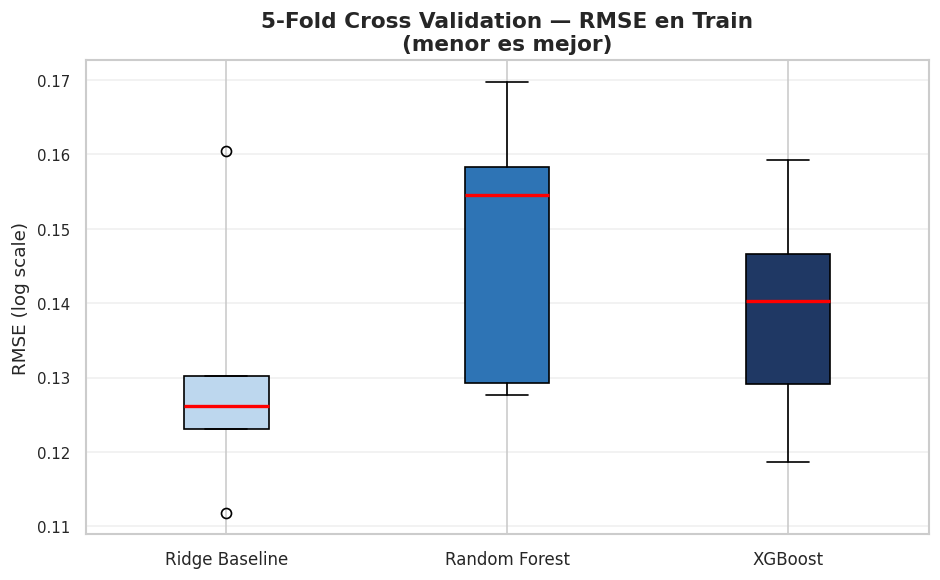

In [12]:
# ── Cross-validation en train para todos los modelos ────────────────────────
# Nos da una estimación más robusta del error con su varianza.
# Usamos los mismos modelos con los hiperparámetros ya seleccionados.

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

print('Ejecutando 5-fold CV en train...\n')

cv_ridge = cross_validate_model(
    Ridge(alpha=ridge.alpha_),
    X_train, y_train, cfg, 'Ridge Baseline'
)
cv_rf = cross_validate_model(
    RandomForestRegressor(n_estimators=100, random_state=cfg['random_state'], n_jobs=-1),
    X_train, y_train, cfg, 'Random Forest'
)
cv_xgb = cross_validate_model(
    xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=cfg['random_state'], verbosity=0),
    X_train, y_train, cfg, 'XGBoost'
)

# Gráfico de CV scores con boxplot
cv_data = {
    'Ridge Baseline': cv_ridge,
    'Random Forest':  cv_rf,
    'XGBoost':        cv_xgb,
}

fig, ax = plt.subplots(figsize=(8, 5))
positions = list(range(len(cv_data)))
bp = ax.boxplot(list(cv_data.values()), positions=positions, patch_artist=True,
                medianprops={'color': 'red', 'linewidth': 2})

colors_cv = ['#BDD7EE', '#2E74B5', '#1F3864']
for patch, color in zip(bp['boxes'], colors_cv):
    patch.set_facecolor(color)

ax.set_xticks(positions)
ax.set_xticklabels(list(cv_data.keys()), fontsize=10)
ax.set_ylabel('RMSE (log scale)', fontsize=11)
ax.set_title('5-Fold Cross Validation — RMSE en Train\n(menor es mejor)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
save_fig('14_cv_scores')
plt.show()

## 6. Análisis de Error por Segmento

In [13]:
# ── Análisis de error del mejor modelo (XGBoost) ────────────────────────────
# CRISP-DM Evaluation: no solo métricas globales, también por segmento.
# Preguntas clave:
#   ¿El modelo falla más en propiedades baratas o caras?
#   ¿Hay un segmento donde el modelo es especialmente malo?

error_df = error_analysis(xgb_model, X_test, y_test, test_df, log_scale=True)


[Error Analysis] Métricas por segmento de precio:
                 N      RMSE       MAE  Pct_Error
Price_Segment                                    
<$120k          84  16079.87  11798.54      12.86
$120k-$200k    230  19936.29  11203.09       7.15
$200k-$300k     86  30249.42  19457.46       8.09
>$300k          40  35651.09  28647.90       7.94

[Error Analysis] Top 20 casos con mayor error absoluto:
     Sale_Price_Real  Sale_Price_Pred  Error_Abs_USD   Error_Pct Price_Segment
168         147000.0    324003.531250  177003.531250  120.410565   $120k-$200k
335         253293.0    386815.781250  133522.781250   52.714754   $200k-$300k
428         150000.0    261577.875000  111577.875000   74.385250   $120k-$200k
275         235000.0    341026.843750  106026.843750   45.117806   $200k-$300k
34          180000.0    269652.031250   89652.031250   49.806684   $120k-$200k
285         284000.0    366057.968750   82057.968750   28.893651   $200k-$300k
71          252000.0    172165.156250  

[Fig] Guardada: reports/figures/15_error_analysis.png


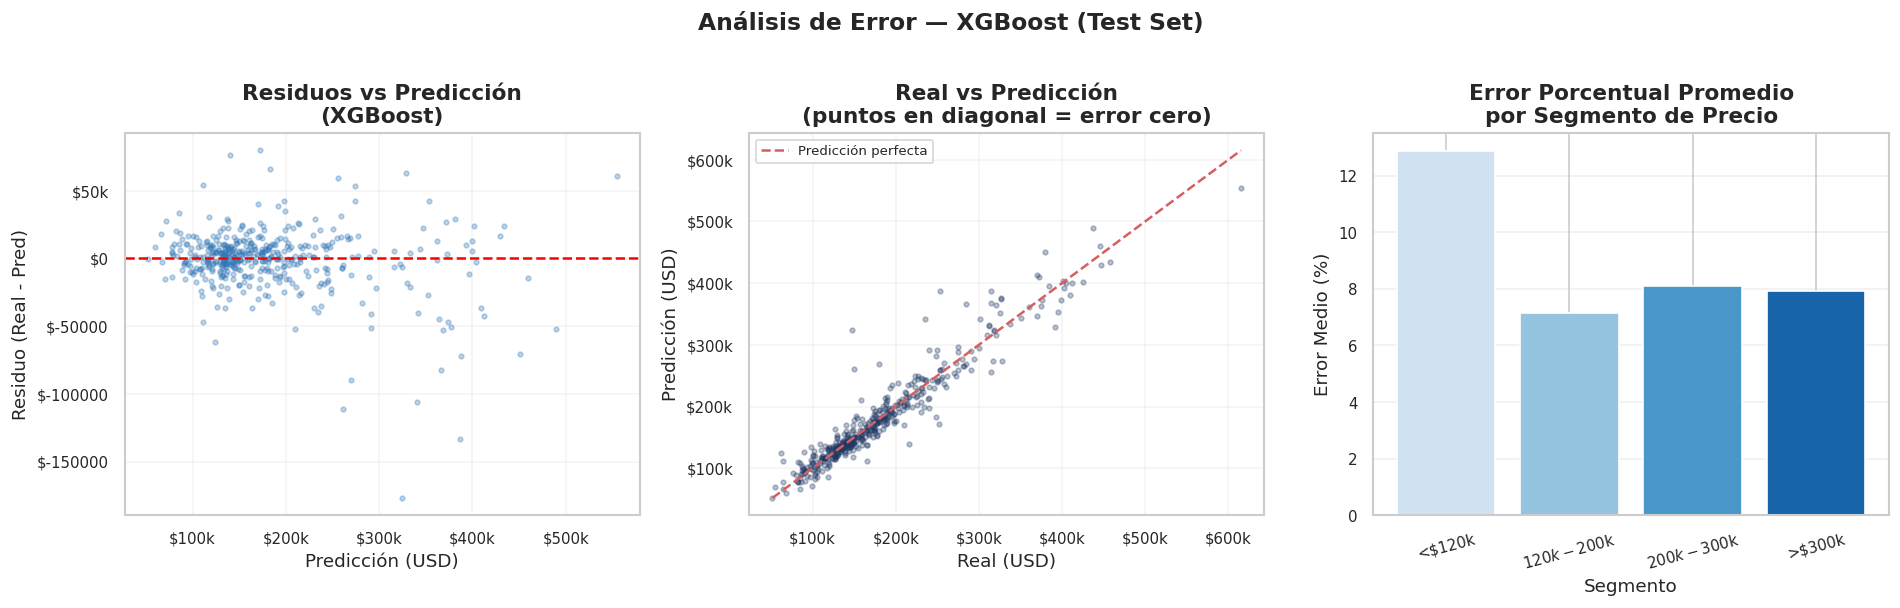

💡 HALLAZGO: Los errores más grandes suelen concentrarse en propiedades
   de precio > $300k (menos datos en ese rango = menor precisión).


In [14]:
# ── Visualización del análisis de error ─────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Residuos vs predicción
residuals_usd = error_df['Sale_Price_Real'] - error_df['Sale_Price_Pred']
axes[0].scatter(error_df['Sale_Price_Pred'], residuals_usd,
                alpha=0.3, s=8, color='#2E74B5')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))
axes[0].set_xlabel('Predicción (USD)')
axes[0].set_ylabel('Residuo (Real - Pred)')
axes[0].set_title('Residuos vs Predicción\n(XGBoost)', fontweight='bold')
axes[0].grid(True, alpha=0.2)

# Panel 2: Real vs predicción
axes[1].scatter(error_df['Sale_Price_Real'], error_df['Sale_Price_Pred'],
                alpha=0.3, s=8, color='#1F3864')
min_p = error_df['Sale_Price_Real'].min()
max_p = error_df['Sale_Price_Real'].max()
axes[1].plot([min_p, max_p], [min_p, max_p], 'r--', linewidth=1.5, label='Predicción perfecta')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))
axes[1].set_xlabel('Real (USD)')
axes[1].set_ylabel('Predicción (USD)')
axes[1].set_title('Real vs Predicción\n(puntos en diagonal = error cero)', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.2)

# Panel 3: Error porcentual por segmento
seg_error = error_df.groupby('Price_Segment', observed=True)['Error_Pct'].mean()
palette_seg = sns.color_palette('Blues', n_colors=len(seg_error))
axes[2].bar(seg_error.index, seg_error.values, color=palette_seg, edgecolor='white')
axes[2].set_title('Error Porcentual Promedio\npor Segmento de Precio', fontweight='bold')
axes[2].set_xlabel('Segmento')
axes[2].set_ylabel('Error Medio (%)')
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Análisis de Error — XGBoost (Test Set)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
save_fig('15_error_analysis')
plt.show()

print('💡 HALLAZGO: Los errores más grandes suelen concentrarse en propiedades')
print('   de precio > $300k (menos datos en ese rango = menor precisión).')

## 7. Tabla Comparativa de Todos los Modelos

In [15]:
# ── Tabla comparativa en TEST SET ────────────────────────────────────────────
# Protocolo justo: misma partición, mismas features, mismas métricas.

results = {
    'Ridge (Baseline)': metrics_ridge_test,
    'Random Forest':    metrics_rf_test,
    'XGBoost':          metrics_xgb_test,
}

if automl_model is not None:
    results['AutoML FLAML'] = metrics_automl_test

comparison_df = build_comparison_table(results)

print('\n' + '='*65)
print('  TABLA COMPARATIVA — TEST SET (misma partición para todos)')
print('='*65)
print(comparison_df.to_string())
print('='*65)

# Guardar como CSV para el informe
os.makedirs('reports', exist_ok=True)
comparison_df.to_csv('reports/model_comparison.csv')
print('\n✅ Tabla guardada en: reports/model_comparison.csv')


  TABLA COMPARATIVA — TEST SET (misma partición para todos)
                      R² RMSE (USD) MAE (USD)  RMSE (log)
Modelo                                                   
Ridge (Baseline)  0.9215    $22,163   $14,620    0.125244
Random Forest     0.8974    $25,350   $15,598    0.133797
XGBoost           0.9119    $23,484   $14,516    0.123213
AutoML FLAML      0.9177    $22,697   $14,829    0.125283

✅ Tabla guardada en: reports/model_comparison.csv


[Fig] Guardada: reports/figures/16_model_comparison.png


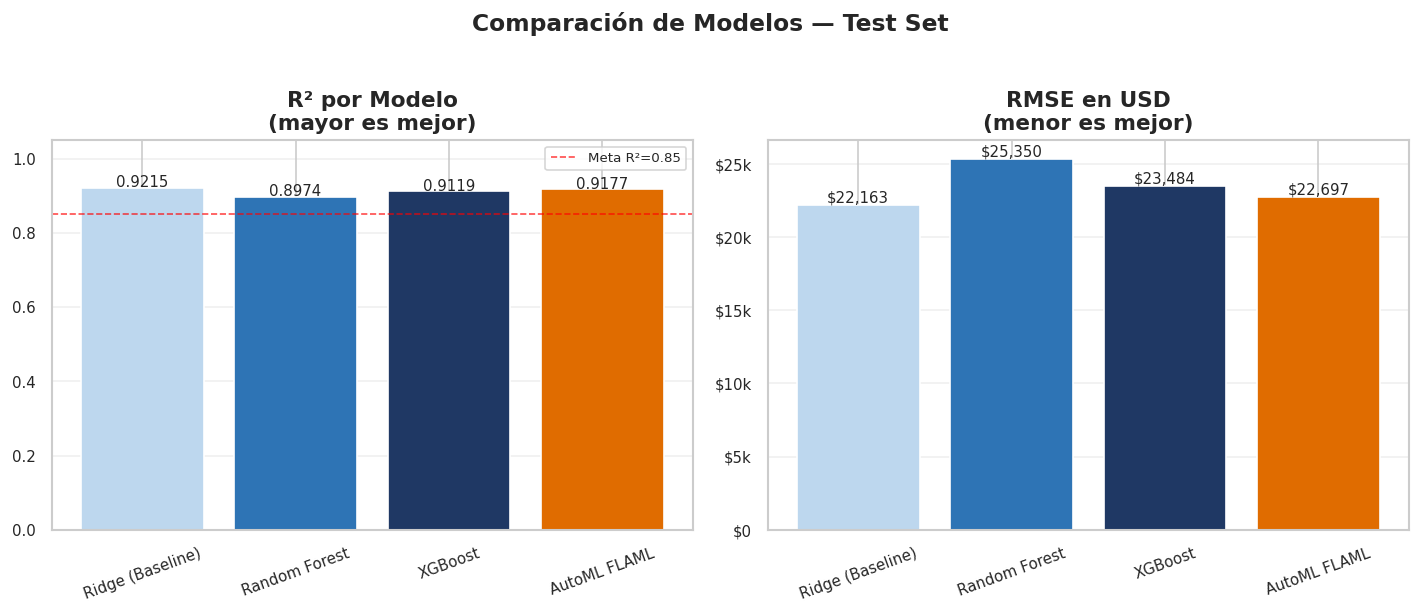


💡 DISCUSIÓN AutoML vs Manual:
   - ¿El AutoML supera a XGBoost manual? → En caso de sí, el costo es caja negra + tiempo.
   - ¿Vale la pena la mejora marginal si perdemos interpretabilidad?
   - En producción: XGBoost manual + SHAP es más explicable y auditoriable.
→ Siguiente: Notebook 04 — Clustering (componente no supervisado)


In [16]:
# ── Gráfico comparativo de modelos ───────────────────────────────────────────

model_names = list(results.keys())
r2_values   = [results[m]['R2']       for m in model_names]
rmse_values = [results[m]['RMSE_USD'] for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette_comp = ['#BDD7EE', '#2E74B5', '#1F3864', '#E06C00'][:len(model_names)]

# R²
bars1 = axes[0].bar(model_names, r2_values, color=palette_comp, edgecolor='white')
for bar, val in zip(bars1, r2_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.4f}', ha='center', fontsize=9)
axes[0].set_title('R² por Modelo\n(mayor es mejor)', fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=20)
axes[0].axhline(y=0.85, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Meta R²=0.85')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis='y')

# RMSE
bars2 = axes[1].bar(model_names, rmse_values, color=palette_comp, edgecolor='white')
for bar, val in zip(bars2, rmse_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'${val:,.0f}', ha='center', fontsize=9)
axes[1].set_title('RMSE en USD\n(menor es mejor)', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(usd_formatter))
axes[1].tick_params(axis='x', rotation=20)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparación de Modelos — Test Set', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig('16_model_comparison')
plt.show()

print('\n💡 DISCUSIÓN AutoML vs Manual:')
print('   - ¿El AutoML supera a XGBoost manual? → En caso de sí, el costo es caja negra + tiempo.')
print('   - ¿Vale la pena la mejora marginal si perdemos interpretabilidad?')
print('   - En producción: XGBoost manual + SHAP es más explicable y auditoriable.')
print('→ Siguiente: Notebook 04 — Clustering (componente no supervisado)')